# 📊 Superstore Sales Analysis & Prediction

## Business Problem
Retail businesses need to understand what drives sales and profitability to make better strategic decisions.

## Objective
- Analyze sales data to uncover key business insights  
- Identify factors influencing revenue and profit  
- Build a machine learning model to predict sales  

## Value
This project demonstrates how data-driven insights can guide business growth and optimization.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
import pandas as pd
import zipfile
import os

zip_file_path = './Superstore_dataset.zip'
extraction_path = './superstore_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Construct the full path to the CSV file
data_file_path = os.path.join(extraction_path, 'Sample - Superstore.csv')

# Load the CSV file into a DataFrame with specified encoding
df = pd.read_csv(data_file_path, encoding='latin1')

# Display the first few rows of the DataFrame
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Overview

The dataset includes:
- Sales and Profit data
- Product categories
- Regional performance
- Order dates

This allows both analytical and predictive modeling.

In [3]:
import pandas as pd
import zipfile
import os

# Assuming data_file_path is already defined from cell 4601d10e
df = pd.read_csv(data_file_path, encoding='latin1')

df.columns = df.columns.str.strip().str.replace(' ', '_')

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

df.drop(['Row_ID','Order_ID','Customer_Name','Product_Name'], axis=1, inplace=True, errors='ignore')

# Create a separate DataFrame for modeling and apply one-hot encoding
df_model = df.copy()
# Drop datetime columns before one-hot encoding for modeling
df_model = df_model.drop(['Order_Date', 'Ship_Date'], axis=1, errors='ignore')
df_model = pd.get_dummies(df_model, drop_first=True)

print("Head of DataFrame for EDA (df):")
display(df.head())
print("\nHead of DataFrame for Modeling (df_model):")
display(df_model.head())

Head of DataFrame for EDA (df):


,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month
0,2016-11-08,11/11/2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136,2016,11
1,2016-11-08,11/11/2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820,2016,11
2,2016-06-12,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714,2016,6
3,2015-10-11,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310,2015,10
4,2015-10-11,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164,2015,10



Head of DataFrame for Modeling (df_model):


,Postal_Code,Sales,Quantity,Discount,Profit,Year,Month,Ship_Mode_Same Day,Ship_Mode_Second Class,Ship_Mode_Standard Class,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,42420,261.9600,2,0.00,41.9136,2016,11,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,42420,731.9400,3,0.00,219.5820,2016,11,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,90036,14.6200,2,0.00,6.8714,2016,6,False,True,False,...,False,False,False,True,False,False,False,False,False,False
3,33311,957.5775,5,0.45,-383.0310,2015,10,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,33311,22.3680,2,0.20,2.5164,2015,10,False,False,True,...,False,False,False,False,False,False,False,True,False,False


## Data Preparation

- Converted date into Year and Month  
- Removed non-informative identifiers  
- Encoded categorical variables  
- Prepared dataset for modeling  

## Exploratory Data Analysis (EDA)

Understanding patterns and extracting business insights.

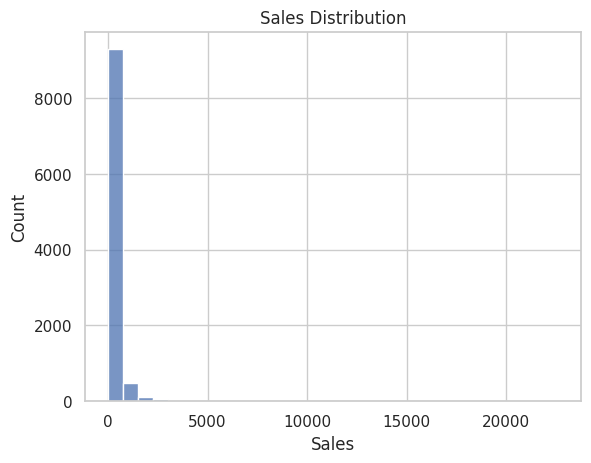

In [4]:
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

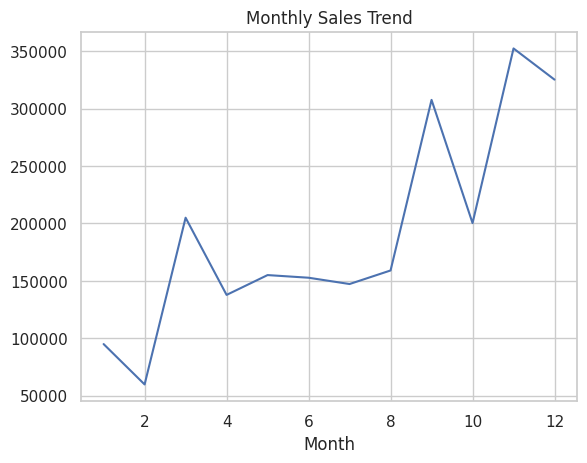

In [5]:
df.groupby('Month')['Sales'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

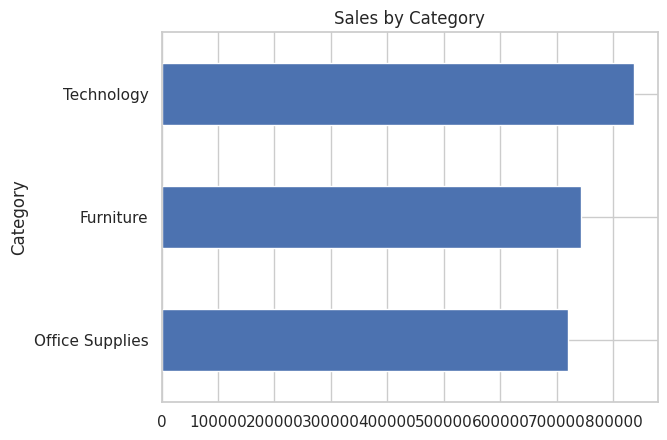

In [6]:
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh')
plt.title("Sales by Category")
plt.show()

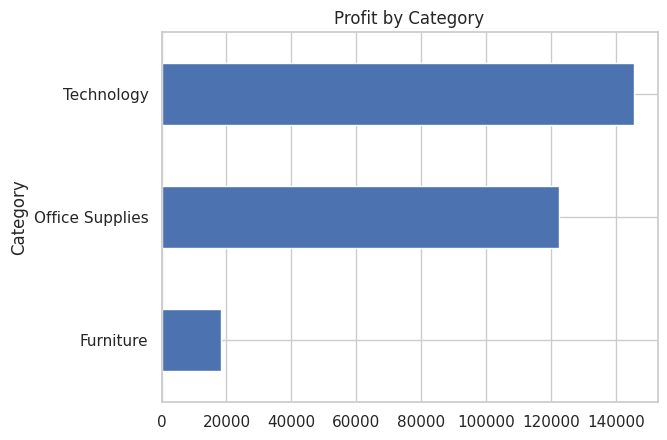

In [7]:
df.groupby('Category')['Profit'].sum().sort_values().plot(kind='barh')
plt.title("Profit by Category")
plt.show()

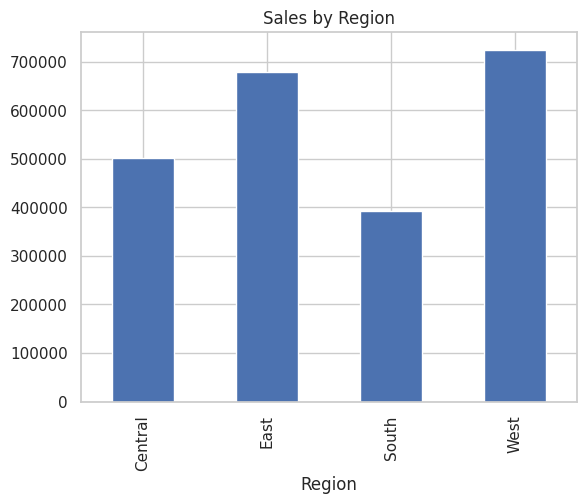

In [8]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

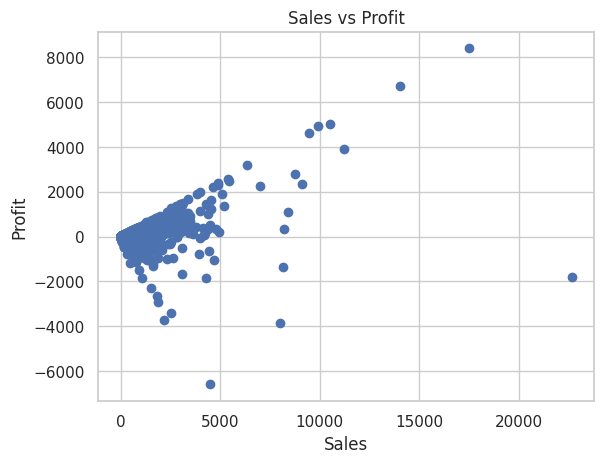

In [9]:
plt.scatter(df['Sales'], df['Profit'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

## Key Business Insights

- Sales distribution shows many small transactions and few large ones  
- Technology category drives the highest revenue  
- Some categories generate high sales but lower profit margins  
- Regional performance varies significantly  
- Higher sales do not always translate into higher profit  

These insights can guide strategic decision-making.

## Model Building

We use:
- Linear Regression (baseline model)
- Random Forest (advanced model)

In [10]:
from sklearn.model_selection import train_test_split

# Ensure non-numeric columns are dropped before creating X
X = df_model.drop('Sales', axis=1)
y = df_model['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [13]:
from sklearn.metrics import r2_score, mean_squared_error

lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression R2:", lr_r2)
print("Random Forest R2:", rf_r2)

Linear Regression R2: 0.2850640763159197
Random Forest R2: 0.505957010049933


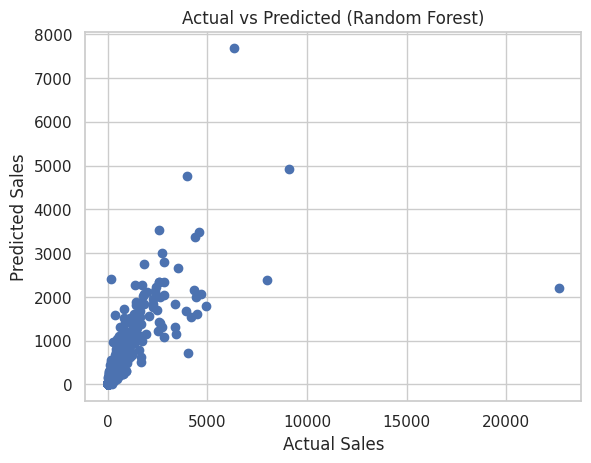

In [14]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

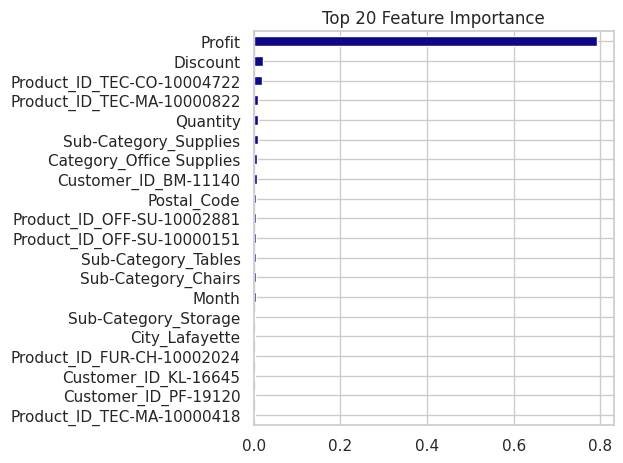

In [18]:
importance = rf_model.feature_importances_
features = X.columns

top_features = pd.Series(importance, index=features).sort_values(ascending=False).head(20)

top_features.sort_values().plot(kind='barh', cmap='plasma')
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.show()

## Model Evaluation

Two regression models were applied for sales prediction:

### 1. Linear Regression
- R² Score: 0.285
- Performance: Weak fit to the data
- Limitation: Unable to capture non-linear relationships in the dataset

### 2. Random Forest Regressor
- R² Score: 0.506
- Performance: Better predictive capability compared to Linear Regression
- Strength: Captures non-linear patterns and feature interactions effectively

### Final Conclusion
Random Forest outperformed Linear Regression due to its ability to model complex relationships in the sales data. However, overall performance suggests that additional feature engineering could further improve predictive accuracy.


### Key Findings
- Technology category is the main revenue driver  
- Regional performance differences present growth opportunities  
- Profit margins vary across categories  

### Business Recommendations
- Invest in high-performing categories  
- Optimize low-profit segments  
- Use predictive modeling for planning  

### Final Note
This project demonstrates how combining data analysis and machine learning can drive better business decisions.